<a href="https://colab.research.google.com/github/lsteffenel/CHPS0906/blob/main/Visualisation_des_poids_des_neurones_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dans cet exemple simple, on crée un réseau avec une seule couche cachée pour identifier MNIST. L'objectif est de visualiser les poids après entraînement.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml


# Lecture du dataset et préparation des données

In [21]:

# Load MNIST data from openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0  # Normalize data

# Convert numpy arrays to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y.astype(int), dtype=torch.long)  # Classification labels

# Split dataset into train (30%) and test (70%) as in original (random_state=0)
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.3 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(0))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


# Création de la classe PyTorch

On crée une couche cachée (hidden) avec 30 neurones.
En sortie, on aurait pu mettre un SoftMax mais ce n'est pas nécessaire pour l'exemple.

In [22]:

# Define a simple MLP model equivalent to hidden_layer_sizes=(40,)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 30)
        #self.relu = nn.ReLU()
        self.fc2 = nn.Linear(30, 10)  # 10 output classes for MNIST

    def forward(self, x):
        x = self.fc1(x)
        #x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLP()

# Set optimizer and loss function similar to scikit-learn's sgd + cross-entropy
optimizer = optim.SGD(model.parameters(), lr=0.2, weight_decay=1e-4)  # alpha corresponds to weight_decay
criterion = nn.CrossEntropyLoss()


## L'entraînement

In [23]:

# Train the model for 8 epochs (max_iter=8)
num_epochs = 8
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/8, Loss: 0.5116
Epoch 2/8, Loss: 0.3286
Epoch 3/8, Loss: 0.3057
Epoch 4/8, Loss: 0.2907
Epoch 5/8, Loss: 0.2899
Epoch 6/8, Loss: 0.2789
Epoch 7/8, Loss: 0.2705
Epoch 8/8, Loss: 0.2670


In [24]:

# Evaluate on train and test partitions
def evaluate(dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

train_acc = evaluate(train_loader)
test_acc = evaluate(test_loader)

print(f"Training set accuracy: {train_acc:.4f}")
print(f"Test set accuracy: {test_acc:.4f}")


Training set accuracy: 0.9279
Test set accuracy: 0.9102


## et l'affichage des poids de chacun des 30 neurones

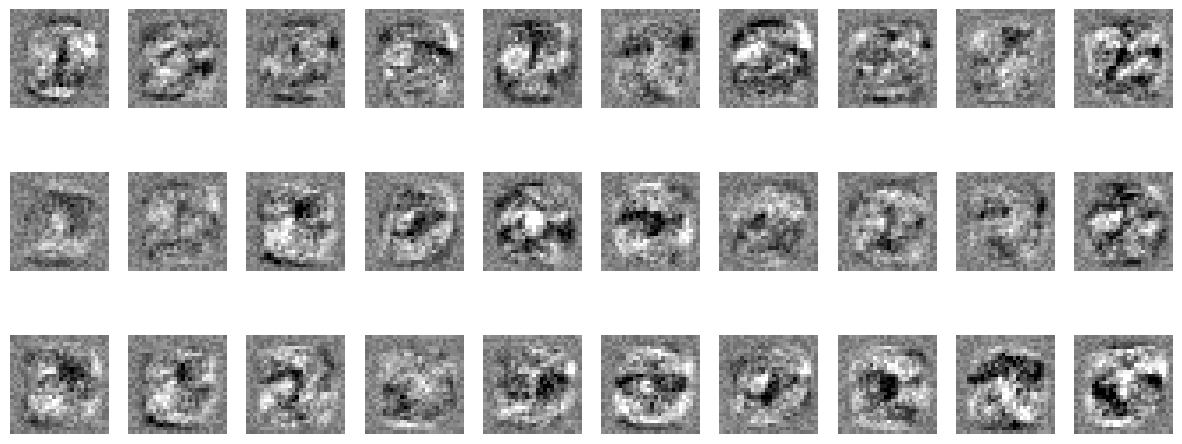

In [25]:

# Plot weights of first layer (equivalent of mlp.coefs_[0])
fig, axes = plt.subplots(3, 10, figsize=(15, 6))
weights = model.fc1.weight.data.cpu().numpy()
vmin, vmax = weights.min(), weights.max()

for i, ax in enumerate(axes.ravel()):
    if i < weights.shape[0]:
        coef = weights[i].reshape(28, 28)
        ax.matshow(coef, cmap="gray", vmin=0.5 * vmin, vmax=0.5 * vmax)
        ax.axis('off')
plt.show()
